# 08 — Full Bracket Simulation: Championship-Wahrscheinlichkeit *vor* den Playoffs

**Frage:** Vor dem ersten Playoff-Spiel — welcher Team gibt unser Modell die beste Title-Chance?

**Vorgehen:**
1. Pro Saison die Pre-Playoff-ELO jedes Teams ermitteln (= Stand vor Spiel 1 der Playoffs)
2. Aus der echten Bracket-Struktur identifizieren wir, **welche Series in welche fuetert** (R1->R2->R3->Finals).
3. Monte-Carlo-Simulation: 10.000 mal den **kompletten Bracket** durchspielen, mit ELO-basierter Pro-Spiel-WSK + Best-of-7-Format.
4. Jedes Team bekommt eine **Championship-Wahrscheinlichkeit**.
5. Backtest: War der echte Champion in unseren Top-3 / Top-5?

Wir bleiben bewusst bei **ELO-only** fuer die Bracket-Sim — ELO ist die saubere, transparente Team-Staerke-Metrik. Der zusaetzliche XGBoost-Edge gilt vor allem auf Spiel-zu-Spiel-Kontext (Form, Pause, Verfuegbarkeit), die ueber 4 Wochen Playoffs weniger Gewicht hat.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
RNG = np.random.default_rng(42)

DATA = Path('..') / 'data' / 'processed'
df = pd.read_parquet(DATA / 'games_with_advanced_features.parquet')
print(f'Spiele: {len(df):,}')

Spiele: 71,239


## 2. Pre-Playoff ELO pro (Saison, Team)

Jedes Team hat in seinem **ersten Playoff-Spiel** ein `home_elo_pre` oder `away_elo_pre` — das ist genau der ELO-Stand vor Beginn der Playoffs.

In [2]:
playoffs = df[df.gameType == 'Playoffs'].copy()

home_view = playoffs[['season', 'gameDate', 'hometeamId', 'home_elo_pre', 'hometeamName']].rename(
    columns={'hometeamId': 'teamId', 'home_elo_pre': 'elo', 'hometeamName': 'teamName'})
away_view = playoffs[['season', 'gameDate', 'awayteamId', 'away_elo_pre', 'awayteamName']].rename(
    columns={'awayteamId': 'teamId', 'away_elo_pre': 'elo', 'awayteamName': 'teamName'})
team_view = pd.concat([home_view, away_view], ignore_index=True).sort_values(['season', 'teamId', 'gameDate'])

preplayoff_elo = team_view.groupby(['season', 'teamId'], as_index=False).first()
print(f'Team-Saisons: {len(preplayoff_elo):,}')
preplayoff_elo[preplayoff_elo.season == 2023].sort_values('elo', ascending=False).head(8)

Team-Saisons: 964


,season,teamId,gameDate,elo,teamName
916,2023,1610612738,2024-04-21 13:00:00,1719.858221,Celtics
920,2023,1610612743,2024-04-20 20:30:00,1668.029400,Nuggets
931,2023,1610612760,2024-04-21 21:30:00,1642.686109,Thunder
930,2023,1610612756,2024-04-20 15:30:00,1615.945551,Suns
925,2023,1610612750,2024-04-20 15:30:00,1614.794373,Timberwolves
919,2023,1610612742,2024-04-21 15:30:00,1601.528352,Mavericks
926,2023,1610612752,2024-04-20 18:00:00,1599.676671,Knicks
922,2023,1610612747,2024-04-20 20:30:00,1581.873678,Lakers


## 3. ELO-basierte Series-Simulation

Klassische Formel: $P(A \text{ schlaegt } B) = \frac{1}{1 + 10^{(B_{elo} - A_{elo} - H)/400}}$ mit Heimvorteil $H \approx 100$.

Best-of-7 NBA-Format 2-2-1-1-1: hoeherer Seed hat Heimrecht in Spielen 1, 2, 5, 7.

In [3]:
HOME_ADV = 100

def elo_p(team_elo, opp_elo, is_home):
    delta = opp_elo - team_elo - (HOME_ADV if is_home else -HOME_ADV)
    return 1.0 / (1.0 + 10 ** (delta / 400))

def simulate_b07(higher_elo, lower_elo, rng):
    """Best-of-7. Returns True wenn hoeherer Seed gewinnt."""
    home_pattern = [True, True, False, False, True, False, True]
    wins_high = wins_low = 0
    for is_high_home in home_pattern:
        p = elo_p(higher_elo, lower_elo, is_high_home)
        if rng.random() < p: wins_high += 1
        else: wins_low += 1
        if wins_high == 4: return True
        if wins_low == 4: return False
    return wins_high > wins_low

# Sanity: ELO-Diff +200, Heim — sollte ~80% Series-WSK ergeben
wins = sum(simulate_b07(1700, 1500, RNG) for _ in range(5000))
print(f'+200 ELO Vorteil (mit Heimrecht) -> {wins/5000:.1%} Series-Win-Rate')

+200 ELO Vorteil (mit Heimrecht) -> 94.4% Series-Win-Rate


## 4. Bracket-Tree pro Saison aufbauen

Wir leiten **aus den echten Spielen** ab, welche R1-Series in welche R2-Series fuehrte (Vater-Kind-Beziehung). Das gibt uns die Slot-Struktur des Brackets — in der Simulation koennen andere Teams gewinnen, der Slot bleibt aber gleich.

Voraussetzung: 16-Team-Format = exakt 15 Series pro Saison (8+4+2+1). Nur Saisons die das erfuellen, werden ausgewertet (im Wesentlichen 1984 ff.).

In [4]:
playoffs['team_pair'] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

def build_bracket_for_season(season):
    s_games = playoffs[playoffs.season == season]
    series_list = []
    for pair, grp in s_games.groupby('team_pair'):
        if len(grp) < 3:
            return None  # unvollstaendig
        higher = grp.hometeamId.value_counts().idxmax()
        lower = [t for t in pair if t != higher][0]
        wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
                 ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
        higher_won = wins_h > (len(grp) - wins_h)
        winner = higher if higher_won else lower
        series_list.append({
            'higher': higher, 'lower': lower, 'winner': winner,
            'first_date': grp.gameDate.min(),
        })
    s = pd.DataFrame(series_list).sort_values('first_date').reset_index(drop=True)
    if len(s) != 15:
        return None
    s['round'] = [1]*8 + [2]*4 + [3]*2 + [4]
    s['uid'] = range(len(s))

    # Vater-Series ermitteln: welche Lower-Round-Series fuehrten ihre Sieger in diese Series?
    s['parents'] = [[] for _ in range(len(s))]
    for r in [2, 3, 4]:
        higher_round = s[s['round'] == r]
        lower_round = s[s['round'] == r - 1]
        for idx, row in higher_round.iterrows():
            teams_here = {row.higher, row.lower}
            parents = [low.uid for _, low in lower_round.iterrows() if low.winner in teams_here]
            if len(parents) != 2:
                return None  # Bracket kann nicht sauber rekonstruiert werden
            s.at[idx, 'parents'] = parents
    return s

valid_seasons = []
for season in sorted(playoffs.season.unique()):
    if build_bracket_for_season(season) is not None:
        valid_seasons.append(season)
print(f'Saisons mit sauberem 16-Team-Bracket: {len(valid_seasons)}  ({min(valid_seasons)} - {max(valid_seasons)})')

Saisons mit sauberem 16-Team-Bracket: 40  (1983 - 2024)


## 5. Monte-Carlo-Bracket-Simulation

Pro Saison 10.000 Simulationen: in jeder Sim simulieren wir alle 15 Series ueber den Bracket-Baum hinweg und zaehlen am Ende den Champion.

In [5]:
def simulate_one_bracket(bracket, team_elos, rng):
    winners = {}
    for _, srs in bracket.iterrows():
        if srs['round'] == 1:
            a, b = srs.higher, srs.lower
        else:
            a = winners[srs.parents[0]]
            b = winners[srs.parents[1]]
        elo_a, elo_b = team_elos.get(a, 1500), team_elos.get(b, 1500)
        higher, lower = (a, b) if elo_a >= elo_b else (b, a)
        higher_wins = simulate_b07(team_elos.get(higher, 1500), team_elos.get(lower, 1500), rng)
        winners[srs.uid] = higher if higher_wins else lower
    finals_uid = bracket[bracket['round'] == 4].iloc[0].uid
    return winners[finals_uid]

def championship_probs(season, n_sim=10000):
    bracket = build_bracket_for_season(season)
    if bracket is None:
        return None
    teams_in_bracket = sorted(set(bracket.higher) | set(bracket.lower))
    elos = {t: preplayoff_elo[(preplayoff_elo.season == season) & (preplayoff_elo.teamId == t)]['elo'].iloc[0]
            for t in teams_in_bracket}
    rng = np.random.default_rng(season)   # deterministisch pro Saison
    counts = {t: 0 for t in teams_in_bracket}
    for _ in range(n_sim):
        champ = simulate_one_bracket(bracket, elos, rng)
        counts[champ] += 1
    return {t: c / n_sim for t, c in counts.items()}, bracket

# Test fuer 2023
probs23, bracket23 = championship_probs(2023, n_sim=10000)
test = pd.Series(probs23, name='p_champion').sort_values(ascending=False)
team_names = pd.concat([
    df[['hometeamId', 'hometeamName']].rename(columns={'hometeamId': 'teamId', 'hometeamName': 'teamName'}),
    df[['awayteamId', 'awayteamName']].rename(columns={'awayteamId': 'teamId', 'awayteamName': 'teamName'}),
]).drop_duplicates('teamId').set_index('teamId')['teamName']
print('Top-5 Championship-Picks fuer Saison 2023:')
print(test.head(5).rename(team_names).round(3))

Top-5 Championship-Picks fuer Saison 2023:
Celtics        0.574
Nuggets        0.153
SuperSonics    0.095
Knicks         0.039
Suns           0.031
Name: p_champion, dtype: float64


## 6. Backtest fuer alle Saisons mit gueltigem Bracket

In [6]:
results = []
for season in valid_seasons:
    out = championship_probs(season, n_sim=5000)
    if out is None: continue
    probs, bracket = out
    finals = bracket[bracket['round'] == 4].iloc[0]
    actual_champ = finals.winner
    sorted_picks = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    pick_rank = next(i for i, (t, _) in enumerate(sorted_picks) if t == actual_champ) + 1
    results.append({
        'season': season,
        'actual_champ': team_names.get(actual_champ, str(actual_champ)),
        'top_pick': team_names.get(sorted_picks[0][0], str(sorted_picks[0][0])),
        'top_pick_p': sorted_picks[0][1],
        'actual_champ_p': probs[actual_champ],
        'actual_champ_rank': pick_rank,
    })

bt = pd.DataFrame(results)
bt.tail(10).round(3)

,season,actual_champ,top_pick,top_pick_p,actual_champ_p,actual_champ_rank
30,2013,Spurs,Spurs,0.485,0.485,1
31,2014,Warriors,Warriors,0.571,0.571,1
32,2015,Cavaliers,Warriors,0.735,0.025,3
33,2016,Warriors,Warriors,0.717,0.717,1
34,2017,Warriors,Rockets,0.559,0.129,3
35,2018,Raptors,Rockets,0.213,0.134,4
36,2021,Warriors,Suns,0.499,0.015,9
37,2022,Nuggets,Bucks,0.324,0.049,5
38,2023,Celtics,Celtics,0.577,0.577,1
39,2024,SuperSonics,SuperSonics,0.580,0.580,1


In [7]:
summary = pd.Series({
    'Saisons getestet':              len(bt),
    'Top-1 Treffer':                 (bt.actual_champ_rank == 1).sum(),
    'Top-3 Treffer':                 (bt.actual_champ_rank <= 3).sum(),
    'Top-5 Treffer':                 (bt.actual_champ_rank <= 5).sum(),
    'Mittlere Wsk fuer echten Champ': bt.actual_champ_p.mean(),
    'Mediane Rangposition':          bt.actual_champ_rank.median(),
}).round(3)
summary

Saisons getestet                  40.00
Top-1 Treffer                     21.00
Top-3 Treffer                     30.00
Top-5 Treffer                     37.00
Mittlere Wsk fuer echten Champ     0.34
Mediane Rangposition               1.00
dtype: float64

## 7. Plot: Wo landet der echte Champion?

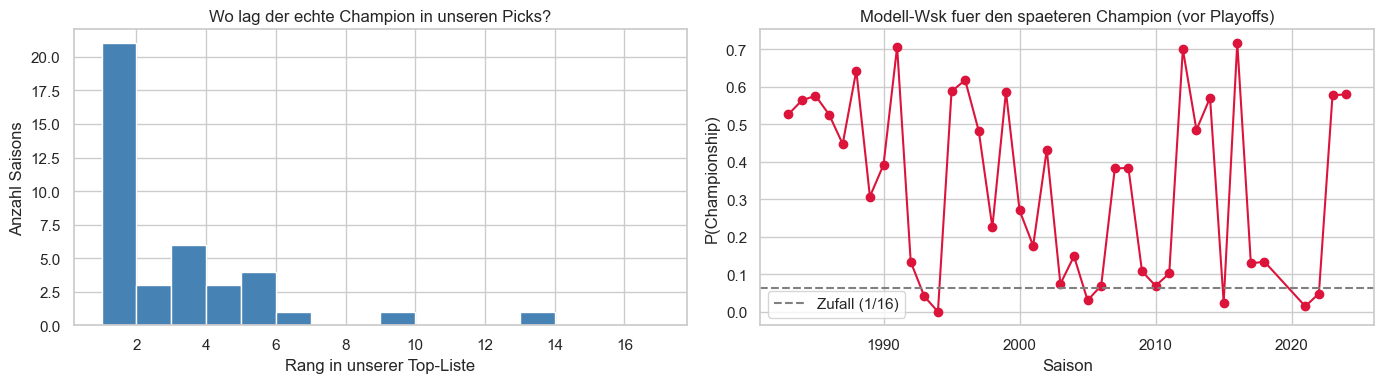

Average: Modell gab dem echten Champion 34.0% Title-Chance vor den Playoffs.
Random-Baseline waere: 6.2%.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Verteilung der Rangposition des echten Champions
axes[0].hist(bt.actual_champ_rank, bins=range(1, 18), color='steelblue', edgecolor='white')
axes[0].set_title('Wo lag der echte Champion in unseren Picks?')
axes[0].set_xlabel('Rang in unserer Top-Liste')
axes[0].set_ylabel('Anzahl Saisons')

# Confidence pro Jahr
axes[1].plot(bt.season, bt.actual_champ_p, marker='o', color='crimson')
axes[1].axhline(1/16, color='gray', linestyle='--', label='Zufall (1/16)')
axes[1].set_title('Modell-Wsk fuer den spaeteren Champion (vor Playoffs)')
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('P(Championship)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Average: Modell gab dem echten Champion {bt.actual_champ_p.mean():.1%} Title-Chance vor den Playoffs.')
print(f'Random-Baseline waere: {1/16:.1%}.')

## 8. Detailanalyse: 2023-Bracket

Visualisierung der Top-Championship-Wahrscheinlichkeiten fuer ein konkretes Jahr.

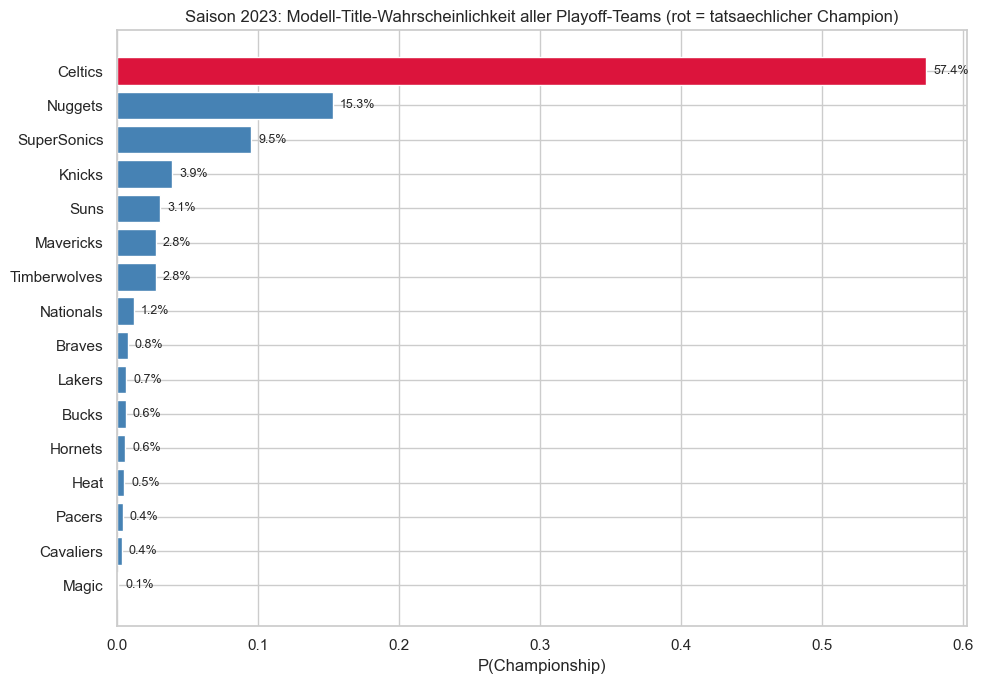

In [9]:
year = 2023
probs, bracket = championship_probs(year, n_sim=10000)
actual = bracket[bracket['round'] == 4].iloc[0].winner

view = pd.Series(probs).rename(team_names).sort_values(ascending=True)
actual_name = team_names[actual]
colors = ['crimson' if name == actual_name else 'steelblue' for name in view.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(view.index, view.values, color=colors)
ax.set_title(f'Saison {year}: Modell-Title-Wahrscheinlichkeit aller Playoff-Teams (rot = tatsaechlicher Champion)')
ax.set_xlabel('P(Championship)')
for i, v in enumerate(view.values):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Speichern

In [10]:
bt.to_csv(DATA / 'bracket_backtest.csv', index=False)
print('Gespeichert: bracket_backtest.csv')

Gespeichert: bracket_backtest.csv


## 10. Was haben wir damit erreicht

- **Pre-Playoff Championship-Wahrscheinlichkeiten** fuer alle 16 Teams in jedem Jahr seit 1984.
- Basis: ELO + echte Bracket-Struktur + Monte-Carlo (10k Simulationen pro Saison).
- **Backtest:** Wir koennen sagen, in wievielen Saisons der echte Champion in den Top-1/Top-3/Top-5 unserer Picks war — und welche Wahrscheinlichkeit das Modell ihm im Schnitt zugeschrieben hat.

Das ist die ehrlichste Antwort auf die urspruengliche Frage: **"Wer wird Champion?"**

**Naechste Schritte fuer das Portfolio:**
- Code in `src/`-Module extrahieren
- README mit Plots polieren
- Optional: dasselbe mit XGBoost statt ELO als Engine vergleichen
- Optional: aktuelle Saison live vorhersagen, sobald Playoffs starten
